In [63]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)


In [64]:
# =========================
# Load Dataset
# =========================
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")

csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

df = pd.read_csv(csv_file)

print("Dataset Shape:", df.shape)
print(df.head())


Using Colab cache for faster access to the 'students-performance-dataset' dataset.
Dataset Shape: (2392, 15)
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0 

In [65]:
# =========================
# Preprocessing
# =========================
df = df.dropna()

X = df.drop(columns=["GradeClass", "StudentID"], errors='ignore')
y = df["GradeClass"]

num_classes = y.nunique()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)



In [66]:
# =========================
# Build Model Function
# =========================
def build_model(neurons, activation, lr, dropout):

    model = Sequential()

    for i, n in enumerate(neurons):

        if i == 0:
            model.add(Dense(n, activation=activation, input_shape=(X_train.shape[1],)))
        else:
            model.add(Dense(n, activation=activation))

        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



In [67]:
# =========================
# Train Function
# =========================
def train_experiment(model, label):

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7
        )
    ]

    print("\nRunning:", label)

    history = model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=85,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    return history


In [68]:

# =========================
# Experiment 1
# =========================
model1 = build_model(
    neurons=[128, 64, 32],
    activation='relu',
    lr=0.001,
    dropout=0.25
)

history1 = train_experiment(model1, "Experiment 1")



Running: Experiment 1
Epoch 1/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3346 - loss: 1.7388 - val_accuracy: 0.5509 - val_loss: 1.3757 - learning_rate: 0.0010
Epoch 2/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5092 - loss: 1.2575 - val_accuracy: 0.6319 - val_loss: 1.1714 - learning_rate: 0.0010
Epoch 3/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5804 - loss: 1.0926 - val_accuracy: 0.6684 - val_loss: 1.0051 - learning_rate: 0.0010
Epoch 4/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6301 - loss: 0.9525 - val_accuracy: 0.7023 - val_loss: 0.8924 - learning_rate: 0.0010
Epoch 5/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6804 - loss: 0.8988 - val_accuracy: 0.7415 - val_loss: 0.8215 - learning_rate: 0.0010
Epoch 6/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6928 - loss: 0.8610 - val_accuracy: 0.7728 - val_loss: 0.7749 - learning_rate: 0.0010
Epoch 7/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6935 

In [69]:
# =========================
# Experiment 2
# =========================
model2 = build_model(
    neurons=[256, 128, 64],
    activation='tanh',
    lr=0.0005,
    dropout=0.20
)

history2 = train_experiment(model2, "Experiment 2")



Running: Experiment 2
Epoch 1/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4797 - loss: 1.4001 - val_accuracy: 0.6214 - val_loss: 1.0172 - learning_rate: 5.0000e-04
Epoch 2/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5451 - loss: 1.2101 - val_accuracy: 0.6841 - val_loss: 0.9441 - learning_rate: 5.0000e-04
Epoch 3/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5817 - loss: 1.1226 - val_accuracy: 0.6841 - val_loss: 0.9213 - learning_rate: 5.0000e-04
Epoch 4/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6157 - loss: 1.0237 - val_accuracy: 0.7206 - val_loss: 0.8870 - learning_rate: 5.0000e-04
Epoch 5/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6412 - loss: 0.9632 - val_accuracy: 0.7337 - val_loss: 0.8602 - learning_rate: 5.0000e-04
Epoch 6/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6549 - loss: 0.9075 - val_accuracy: 0.7441 - val_loss: 0.8422 - learning_rate: 5.0000e-04
Epoch 7/85
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 

In [70]:
# =========================
# Evaluation Function
# =========================
def evaluate(model, history):

    pred = model.predict(X_test, verbose=0)
    pred_classes = np.argmax(pred, axis=1)

    acc = accuracy_score(y_test, pred_classes)
    loss = min(history.history['val_loss'])

    return acc, loss, pred_classes


acc1, loss1, pred1 = evaluate(model1, history1)
acc2, loss2, pred2 = evaluate(model2, history2)



In [71]:
# =========================
# Results Table
# =========================
results = pd.DataFrame({
    "Experiment": ["Exp1-ReLU", "Exp2-Tanh"],
    "Accuracy": [acc1, acc2],
    "Val Loss": [loss1, loss2]
})

print("\nResults")
print(results)




Results
  Experiment  Accuracy  Val Loss
0  Exp1-ReLU  0.843424  0.557751
1  Exp2-Tanh  0.797495  0.652682


In [72]:
# =========================
# Best Model
# =========================
if acc1 >= acc2:
    best_model = model1
    best_pred = pred1
    best_name = "Experiment 1"
else:
    best_model = model2
    best_pred = pred2
    best_name = "Experiment 2"

print("\nBest:", best_name)




Best: Experiment 1


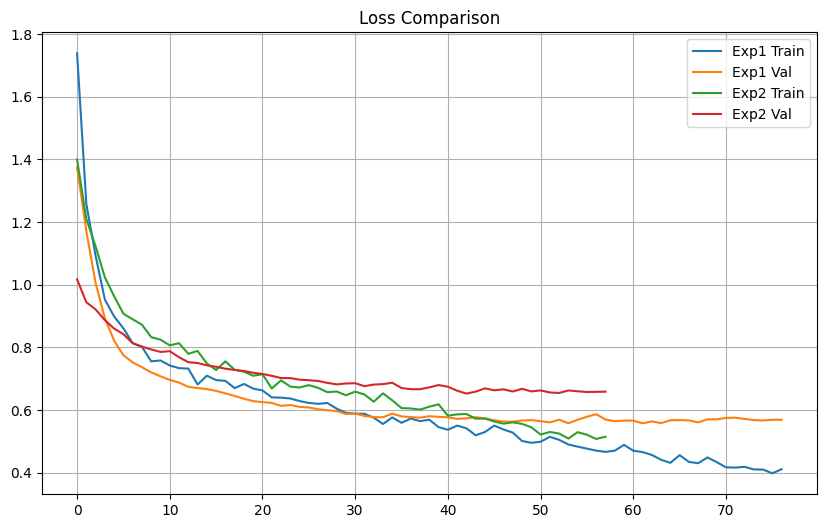

In [73]:
# =========================
# Plot Loss
# =========================
plt.figure(figsize=(10,6))

plt.plot(history1.history['loss'], label='Exp1 Train')
plt.plot(history1.history['val_loss'], label='Exp1 Val')

plt.plot(history2.history['loss'], label='Exp2 Train')
plt.plot(history2.history['val_loss'], label='Exp2 Val')

plt.title("Loss Comparison")
plt.legend()
plt.grid()
plt.show()


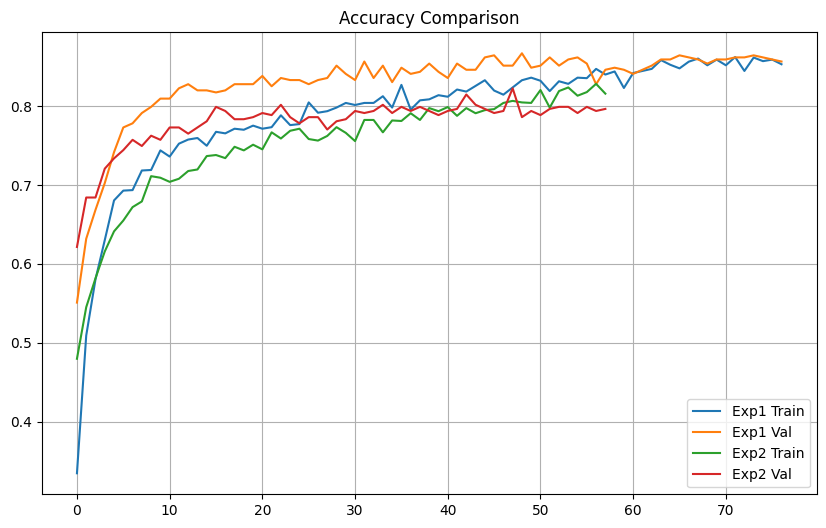

In [74]:
# =========================
# Plot Accuracy
# =========================
plt.figure(figsize=(10,6))

plt.plot(history1.history['accuracy'], label='Exp1 Train')
plt.plot(history1.history['val_accuracy'], label='Exp1 Val')

plt.plot(history2.history['accuracy'], label='Exp2 Train')
plt.plot(history2.history['val_accuracy'], label='Exp2 Val')

plt.title("Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()



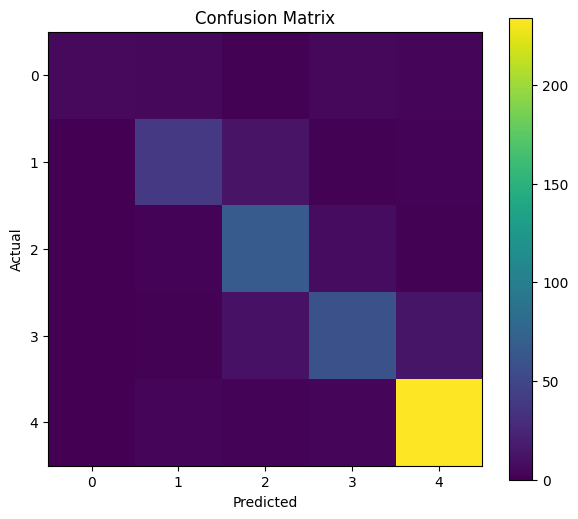

In [75]:
# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [76]:
# =========================
# Final Report
# =========================
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.78      0.72      0.75        54
         2.0       0.72      0.86      0.78        78
         3.0       0.76      0.70      0.73        83
         4.0       0.92      0.96      0.94       243

    accuracy                           0.84       479
   macro avg       0.84      0.71      0.73       479
weighted avg       0.85      0.84      0.84       479

